In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math 

car_data = pd.read_csv("./car_dataset.csv")
seller_data = pd.read_csv("./seller_dataset.csv")
raw_car_data = car_data.copy() 
raw_seller_data = seller_data.copy()

In [3]:
car_data.head(50)


,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,fuel_system,transmission,drive_type,fuel_consumption,brand,grade,year_of_manufacture,car_name,price (AUD)
0,17042,Domestic assembly,New car,Truck,0 Km,White,gray,2-door,2-seat,Petrol\t1.0 L,NaN,Manual,RFD - Rear-wheel drive,L/100Km,Suzuki,Super Carry Truck,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411
1,53794,Imported,New car,SUV,0 Km,Black,Black,5-door,7-seat,Petrol\t3.4 L,NaN,Automatic,AWD - 4-wheel drive (AWD),10\tL/100Km,Toyota,Land Cruiser,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050
2,73954,Domestic assembly,New car,Crossover,0 Km,Silver,Brown,5-door,8-seat,Petrol\t2.0 L,NaN,Automatic,RFD - Rear-wheel drive,L/100Km,Toyota,Innova,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930
3,74150,Imported,New car,SUV,0 Km,White,Black,5-door,5-seat,Petrol\t1.8 L,NaN,Automatic,FWD - Front-wheel drive,L/100Km,Toyota,Corolla Cross,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376
4,87573,Domestic assembly,New car,Crossover,0 Km,Silver,gray,5-door,8-seat,Petrol\t2.0 L,NaN,Automatic,RFD - Rear-wheel drive,L/100Km,Toyota,Innova,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209
5,97011,Domestic assembly,New car,Van/Minivan,0 Km,White,gray,5-door,2-seat,Petrol\t1.0 L,NaN,Manual,RFD - Rear-wheel drive,7\tL/100Km,Suzuki,Super Carry Van,2023.0,Suzuki Super Carry Van Blind Van 2023,12105.29011
6,101726,Domestic assembly,New car,SUV,0 Km,White,Black,5-door,7-seat,Petrol\t1.5 L,NaN,Automatic,FWD - Front-wheel drive,L/100Km,Honda,CRV,2023.0,Honda CRV L 2023 car,39838.14539
7,135739,Imported,New car,SUV,0 Km,Copper,Black,5-door,7-seat,Petrol\t2.7 L,NaN,Automatic,RFD - Rear-wheel drive,L/100Km,Toyota,Fortuner,2023.0,Toyota Fortuner 2.7L 4x2 AT 2023,40485.92011
8,142495,Domestic assembly,New car,4x4,0 Km,Grey,Black,4-door,5-seat,Diesel\t2.2 L,Single turbo oil injection,Automatic,RFD - Rear-wheel drive,7\tL/100Km,Ford,Ranger,2023.0,Ford Ranger XLS 2.0L 4x2 AT 2023,27854.31303
9,143308,Domestic assembly,New car,4x4,0 Km,Black,Black,4-door,5-seat,Diesel\t2.2 L,Single turbo oil injection,Automatic,4WD - Four-wheel drive (4WD),7\tL/100Km,Ford,Ranger,2023.0,Ford Ranger XLT 2.0L 4x4 AT 2023,33603.31369


In [14]:
print(car_data.columns.tolist())

['ad_id', 'origin', 'condition', 'car_model', 'mileage', 'exterior_color', 'interior_color', 'num_of_doors', 'seating_capacity', 'engine', 'fuel_system', 'transmission', 'drive_type', 'fuel_consumption', 'brand', 'grade', 'year_of_manufacture', 'car_name', 'price (AUD)', 'type_of_engine', 'engine_capacity', 'normalised_engine_capacity', 'normalised_num_of_doors', 'normalised_seating_capacity', 'normalised_fuel_consumption', 'normalised_price (AUD)']


In [12]:
#checking the formats of data entered and which part of the data is useful

# def peek(col, n=15):
#     print(col, "->", car_data[col].dtype)
#     print(pd.Series(car_data[col].astype(str).str.strip().unique()).to_list(), "\n")

# peek('num_of_doors'); peek('seating_capacity'); peek('fuel_consumption'); peek('mileage'); peek('price (AUD)'); peek('engine')


def peek(col, n=50):
    print(col, "->", car_data[col].dtype)
    print(pd.Series(car_data[col].astype(str).str.strip().unique()).to_list(), "\n")
    

peek("num_of_doors"); peek("seating_capacity"); peek('fuel_consumption'); peek('mileage'); peek('price (AUD)'); 
peek('engine')

num_of_doors -> int64
['2', '5', '4', '6', '1', '3', '45', '44', '7', '54', '0', '42'] 

seating_capacity -> int64
['2', '7', '8', '5', '3', '4', '6', '16', '20', '47', '10', '29', '11', '9', '42', '15', '17', '12', '38', '30', '1', '44', '0', '46'] 

fuel_consumption -> float64
['nan', '10.0', '7.0', '9.0', '6.0', '8.0', '5.0', '15.0', '16.0', '4.0', '12.0', '11.0', '2.0', '20.0', '13.0', '14.0', '0.0', '65.0', '66.0', '17.0', '42.0', '18.0', '3.0', '1.0', '565.0', '68.0', '7.5', '100.0', '77.0', '7.7', '55.0', '40.0', '10000.0', '592.0', '8.5', '89.0', '83.0', '85.0', '6500.0', '75.0', '5.5', '98.0', '8.7', '5.8', '100000.0', '225.0', '5.7', '7.8', '6.8', '4288.0', '6.5', '111.0', '200000.0', '58.0', '45.0'] 

mileage -> int64
['0', '78', '59', '85', '62', '8', '90', '83', '10', '26', '800', '150', '46', '300', '500', '3', '60', '86', '73', '40', '11', '170', '87', '13', '79', '67', '15', '4', '2', '129', '50', '5', '16', '36', '68', '1', '89', '41', '76', '82', '52', '25', '57', '23

In [13]:
# lets start with "num_of_doors", "seating_capacity", "milage" and "fuel_consumption" as they have similar structure --> number-text, we can get rid of just the "text" part here
numerical_cols = ['mileage', 'num_of_doors', 'seating_capacity', 'fuel_consumption', 'price (AUD)']

for col in numerical_cols:
    car_data[col] = pd.to_numeric(
        car_data[col].astype(str).str.extract(r'^(\d+(?:\.\d+)?)', expand=False),
        errors='coerce'
    )
    
# car_data[numerical_cols].dtypes
# car_data[numerical_cols].head(10)
car_data.head(50)


,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,...,year_of_manufacture,car_name,price (AUD),type_of_engine,engine_capacity,normalised_engine_capacity,normalised_num_of_doors,normalised_seating_capacity,normalised_fuel_consumption,normalised_price (AUD)
0,17042,domestic assembly,new car,truck,0,white,gray,2,2,Petrol\t1.0 L,...,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,petrol,1.0,0.071429,0.037037,0.042553,NaN,0.004611
1,53794,imported,new car,suv,0,black,black,5,7,Petrol\t3.4 L,...,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,petrol,3.4,0.261905,0.092593,0.148936,0.000050,0.074074
2,73954,domestic assembly,new car,crossover,0,silver,brown,5,8,Petrol\t2.0 L,...,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.016389
3,74150,imported,new car,suv,0,white,black,5,5,Petrol\t1.8 L,...,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,petrol,1.8,0.134921,0.092593,0.106383,NaN,0.013963
4,87573,domestic assembly,new car,crossover,0,silver,gray,5,8,Petrol\t2.0 L,...,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.015741
5,97011,domestic assembly,new car,van/minivan,0,white,gray,5,2,Petrol\t1.0 L,...,2023.0,Suzuki Super Carry Van Blind Van 2023,12105.29011,petrol,1.0,0.071429,0.092593,0.042553,0.000035,0.005537
6,101726,domestic assembly,new car,suv,0,white,black,5,7,Petrol\t1.5 L,...,2023.0,Honda CRV L 2023 car,39838.14539,petrol,1.5,0.111111,0.092593,0.148936,NaN,0.018222
7,135739,imported,new car,suv,0,copper,black,5,7,Petrol\t2.7 L,...,2023.0,Toyota Fortuner 2.7L 4x2 AT 2023,40485.92011,petrol,2.7,0.206349,0.092593,0.148936,NaN,0.018519
8,142495,domestic assembly,new car,4x4,0,grey,black,4,5,Diesel\t2.2 L,...,2023.0,Ford Ranger XLS 2.0L 4x2 AT 2023,27854.31303,diesel,2.2,0.166667,0.074074,0.106383,0.000035,0.012741
9,143308,domestic assembly,new car,4x4,0,black,black,4,5,Diesel\t2.2 L,...,2023.0,Ford Ranger XLT 2.0L 4x4 AT 2023,33603.31369,diesel,2.2,0.166667,0.074074,0.106383,0.000035,0.015370


In [15]:
# "Price" colmn -> check if there are only digits or any extra things, if yes--> convert it to number then round it off to the closest integer.


#split engine into engine_Type and Engine_capacity

split_cols = car_data['engine'].astype(str).str.split('\t', n=1, expand=True)

car_data['type_of_engine'] = split_cols[0].str.strip().str.title()

car_data['engine_capacity'] = (
    split_cols[1]
    .str.replace('L', '', case=False, regex=False)
    .str.strip()
    .astype(str)
    .str.extract(r'^(\d+(?:\.\d+)?)', expand=False)
    .pipe(pd.to_numeric, errors='coerce')
)


car_data.head(50)
peek('type_of_engine')

#car_data.drop(columns=['engine'], inplace=True)


type_of_engine -> object
['Petrol', 'Diesel', 'Hybrid', 'Electric', '-'] 



In [16]:
for col in car_data.columns:
    print(col, "-->",car_data[col].dtype)

ad_id --> int64
origin --> object
condition --> object
car_model --> object
mileage --> int64
exterior_color --> object
interior_color --> object
num_of_doors --> int64
seating_capacity --> int64
engine --> object
fuel_system --> object
transmission --> object
drive_type --> object
fuel_consumption --> float64
brand --> object
grade --> object
year_of_manufacture --> float64
car_name --> object
price (AUD) --> float64
type_of_engine --> object
engine_capacity --> float64
normalised_engine_capacity --> float64
normalised_num_of_doors --> float64
normalised_seating_capacity --> float64
normalised_fuel_consumption --> float64
normalised_price (AUD) --> float64


In [17]:
text_entries = ['origin', 'condition', 'car_model', 'exterior_color', 'interior_color', 'type_of_engine',
'fuel_system', 'transmission', 'drive_type', 'brand', 'grade']

for cols in text_entries:
    car_data[cols] = car_data[cols].astype(str).str.lower()
    
    
car_data.head(10)

,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,...,year_of_manufacture,car_name,price (AUD),type_of_engine,engine_capacity,normalised_engine_capacity,normalised_num_of_doors,normalised_seating_capacity,normalised_fuel_consumption,normalised_price (AUD)
0,17042,domestic assembly,new car,truck,0,white,gray,2,2,Petrol\t1.0 L,...,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,petrol,1.0,0.071429,0.037037,0.042553,NaN,0.004611
1,53794,imported,new car,suv,0,black,black,5,7,Petrol\t3.4 L,...,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,petrol,3.4,0.261905,0.092593,0.148936,0.000050,0.074074
2,73954,domestic assembly,new car,crossover,0,silver,brown,5,8,Petrol\t2.0 L,...,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.016389
3,74150,imported,new car,suv,0,white,black,5,5,Petrol\t1.8 L,...,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,petrol,1.8,0.134921,0.092593,0.106383,NaN,0.013963
4,87573,domestic assembly,new car,crossover,0,silver,gray,5,8,Petrol\t2.0 L,...,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.015741
5,97011,domestic assembly,new car,van/minivan,0,white,gray,5,2,Petrol\t1.0 L,...,2023.0,Suzuki Super Carry Van Blind Van 2023,12105.29011,petrol,1.0,0.071429,0.092593,0.042553,0.000035,0.005537
6,101726,domestic assembly,new car,suv,0,white,black,5,7,Petrol\t1.5 L,...,2023.0,Honda CRV L 2023 car,39838.14539,petrol,1.5,0.111111,0.092593,0.148936,NaN,0.018222
7,135739,imported,new car,suv,0,copper,black,5,7,Petrol\t2.7 L,...,2023.0,Toyota Fortuner 2.7L 4x2 AT 2023,40485.92011,petrol,2.7,0.206349,0.092593,0.148936,NaN,0.018519
8,142495,domestic assembly,new car,4x4,0,grey,black,4,5,Diesel\t2.2 L,...,2023.0,Ford Ranger XLS 2.0L 4x2 AT 2023,27854.31303,diesel,2.2,0.166667,0.074074,0.106383,0.000035,0.012741
9,143308,domestic assembly,new car,4x4,0,black,black,4,5,Diesel\t2.2 L,...,2023.0,Ford Ranger XLT 2.0L 4x4 AT 2023,33603.31369,diesel,2.2,0.166667,0.074074,0.106383,0.000035,0.015370


In [19]:
#Min-Max Normalization Formula: x' = (x - min) / (max - min)

numeric_cols = ["engine_capacity", "num_of_doors", "seating_capacity", "fuel_consumption", "price (AUD)"]

for col in numeric_cols:
    if col in car_data.columns:
        min_val = car_data[col].min()
        max_val = car_data[col].max()
        car_data["normalised_" + col] = (car_data[col] - min_val) / (max_val - min_val)


car_data.head(10)

,ad_id,origin,condition,car_model,mileage,exterior_color,interior_color,num_of_doors,seating_capacity,engine,...,year_of_manufacture,car_name,price (AUD),type_of_engine,engine_capacity,normalised_engine_capacity,normalised_num_of_doors,normalised_seating_capacity,normalised_fuel_consumption,normalised_price (AUD)
0,17042,domestic assembly,new car,truck,0,white,gray,2,2,Petrol\t1.0 L,...,2022.0,Suzuki Super Carry Truck 1.0 MT 2022,10080.99411,petrol,1.0,0.071429,0.037037,0.042553,NaN,0.004611
1,53794,imported,new car,suv,0,black,black,5,7,Petrol\t3.4 L,...,2022.0,Toyota Land Cruiser 3.5 V6 2022,161943.68050,petrol,3.4,0.261905,0.092593,0.148936,0.000050,0.074074
2,73954,domestic assembly,new car,crossover,0,silver,brown,5,8,Petrol\t2.0 L,...,2023.0,Toyota Innova G 2.0 AT 2023 car,35830.03930,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.016389
3,74150,imported,new car,suv,0,white,black,5,5,Petrol\t1.8 L,...,2023.0,Toyota Corolla Cross 1.8G 2023,30526.38376,petrol,1.8,0.134921,0.092593,0.106383,NaN,0.013963
4,87573,domestic assembly,new car,crossover,0,silver,gray,5,8,Petrol\t2.0 L,...,2022.0,Toyota Innova G 2.0 AT 2022 car,34413.03209,petrol,2.0,0.150794,0.092593,0.170213,NaN,0.015741
5,97011,domestic assembly,new car,van/minivan,0,white,gray,5,2,Petrol\t1.0 L,...,2023.0,Suzuki Super Carry Van Blind Van 2023,12105.29011,petrol,1.0,0.071429,0.092593,0.042553,0.000035,0.005537
6,101726,domestic assembly,new car,suv,0,white,black,5,7,Petrol\t1.5 L,...,2023.0,Honda CRV L 2023 car,39838.14539,petrol,1.5,0.111111,0.092593,0.148936,NaN,0.018222
7,135739,imported,new car,suv,0,copper,black,5,7,Petrol\t2.7 L,...,2023.0,Toyota Fortuner 2.7L 4x2 AT 2023,40485.92011,petrol,2.7,0.206349,0.092593,0.148936,NaN,0.018519
8,142495,domestic assembly,new car,4x4,0,grey,black,4,5,Diesel\t2.2 L,...,2023.0,Ford Ranger XLS 2.0L 4x2 AT 2023,27854.31303,diesel,2.2,0.166667,0.074074,0.106383,0.000035,0.012741
9,143308,domestic assembly,new car,4x4,0,black,black,4,5,Diesel\t2.2 L,...,2023.0,Ford Ranger XLT 2.0L 4x4 AT 2023,33603.31369,diesel,2.2,0.166667,0.074074,0.106383,0.000035,0.015370


In [27]:
# Statistics Computation - mean, median, mode, standard deviation, and range
stats_cols = ['price (AUD)', 'mileage', 'year_of_manufacture']

# create dict{} for the result
statistics = {}

for col in stats_cols:
    series = car_data[col].dropna() 
    
    mean_val = np.mean(series) #mean
    median_val = np.median(series) #median
    mode_series = series.mode() #mode
    mode_val = mode_series.iloc[0] if not mode_series.empty else None
    
    std_val = np.std(series, ddof=1)  #standard deviation
    range_val = np.max(series) - np.min(series) #range
    
    statistics[col] = {
        'mean': round(mean_val, 2),
        'median': round(median_val, 2),
        'mode': round(mode_val, 2) if mode_val is not None else None,
        'std_dev': round(std_val, 2),
        'range': round(range_val, 2)
    }

In [28]:
# Print the Statistics Computation result
for col, stats_dict in statistics.items():
    print(f"\nStatistics for {col}:")
    for stat, value in stats_dict.items():
        print(f"  {stat:<10}: {value}")


Statistics for price (AUD):
  mean      : 42843.17
  median    : 24939.33
  mode      : 40485.92
  std_dev   : 78585.58
  range     : 2186239.69

Statistics for mileage:
  mean      : 42.11
  median    : 20.0
  mode      : 0
  std_dev   : 74.87
  range     : 999

Statistics for year_of_manufacture:
  mean      : 2017.32
  median    : 2019.0
  mode      : 2023.0
  std_dev   : 5.33
  range     : 33.0


In [38]:
# Work with outliers

# Select Numeric Colunms
numeric_cols = cleaned_car_data.select_dtypes(include=['float64', 'int64']).columns.tolist()


for col in numeric_cols:
    Q1 = cleaned_car_data[col].quantile(0.25)
    Q3 = cleaned_car_data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Show outliers
    outliers = cleaned_car_data[(cleaned_car_data[col] < lower_bound) | (cleaned_car_data[col] > upper_bound)]
    print(f"{col}: {len(outliers)} outliers")

    # Filter non-outlier
    cleaned_car_data = cleaned_car_data[
        (cleaned_car_data[col] >= lower_bound) & (cleaned_car_data[col] <= upper_bound)
    ]

print(f"\nCleaned dataset shape: {cleaned_car_data.shape}")

ad_id: 233 outliers
mileage: 0 outliers
num_of_doors: 0 outliers
seating_capacity: 0 outliers
fuel_consumption: 0 outliers
year_of_manufacture: 84 outliers
price (AUD): 0 outliers
engine_capacity: 0 outliers
normalised_engine_capacity: 0 outliers
normalised_num_of_doors: 0 outliers
normalised_seating_capacity: 0 outliers
normalised_fuel_consumption: 0 outliers
normalised_price (AUD): 0 outliers

Cleaned dataset shape: (4842, 26)


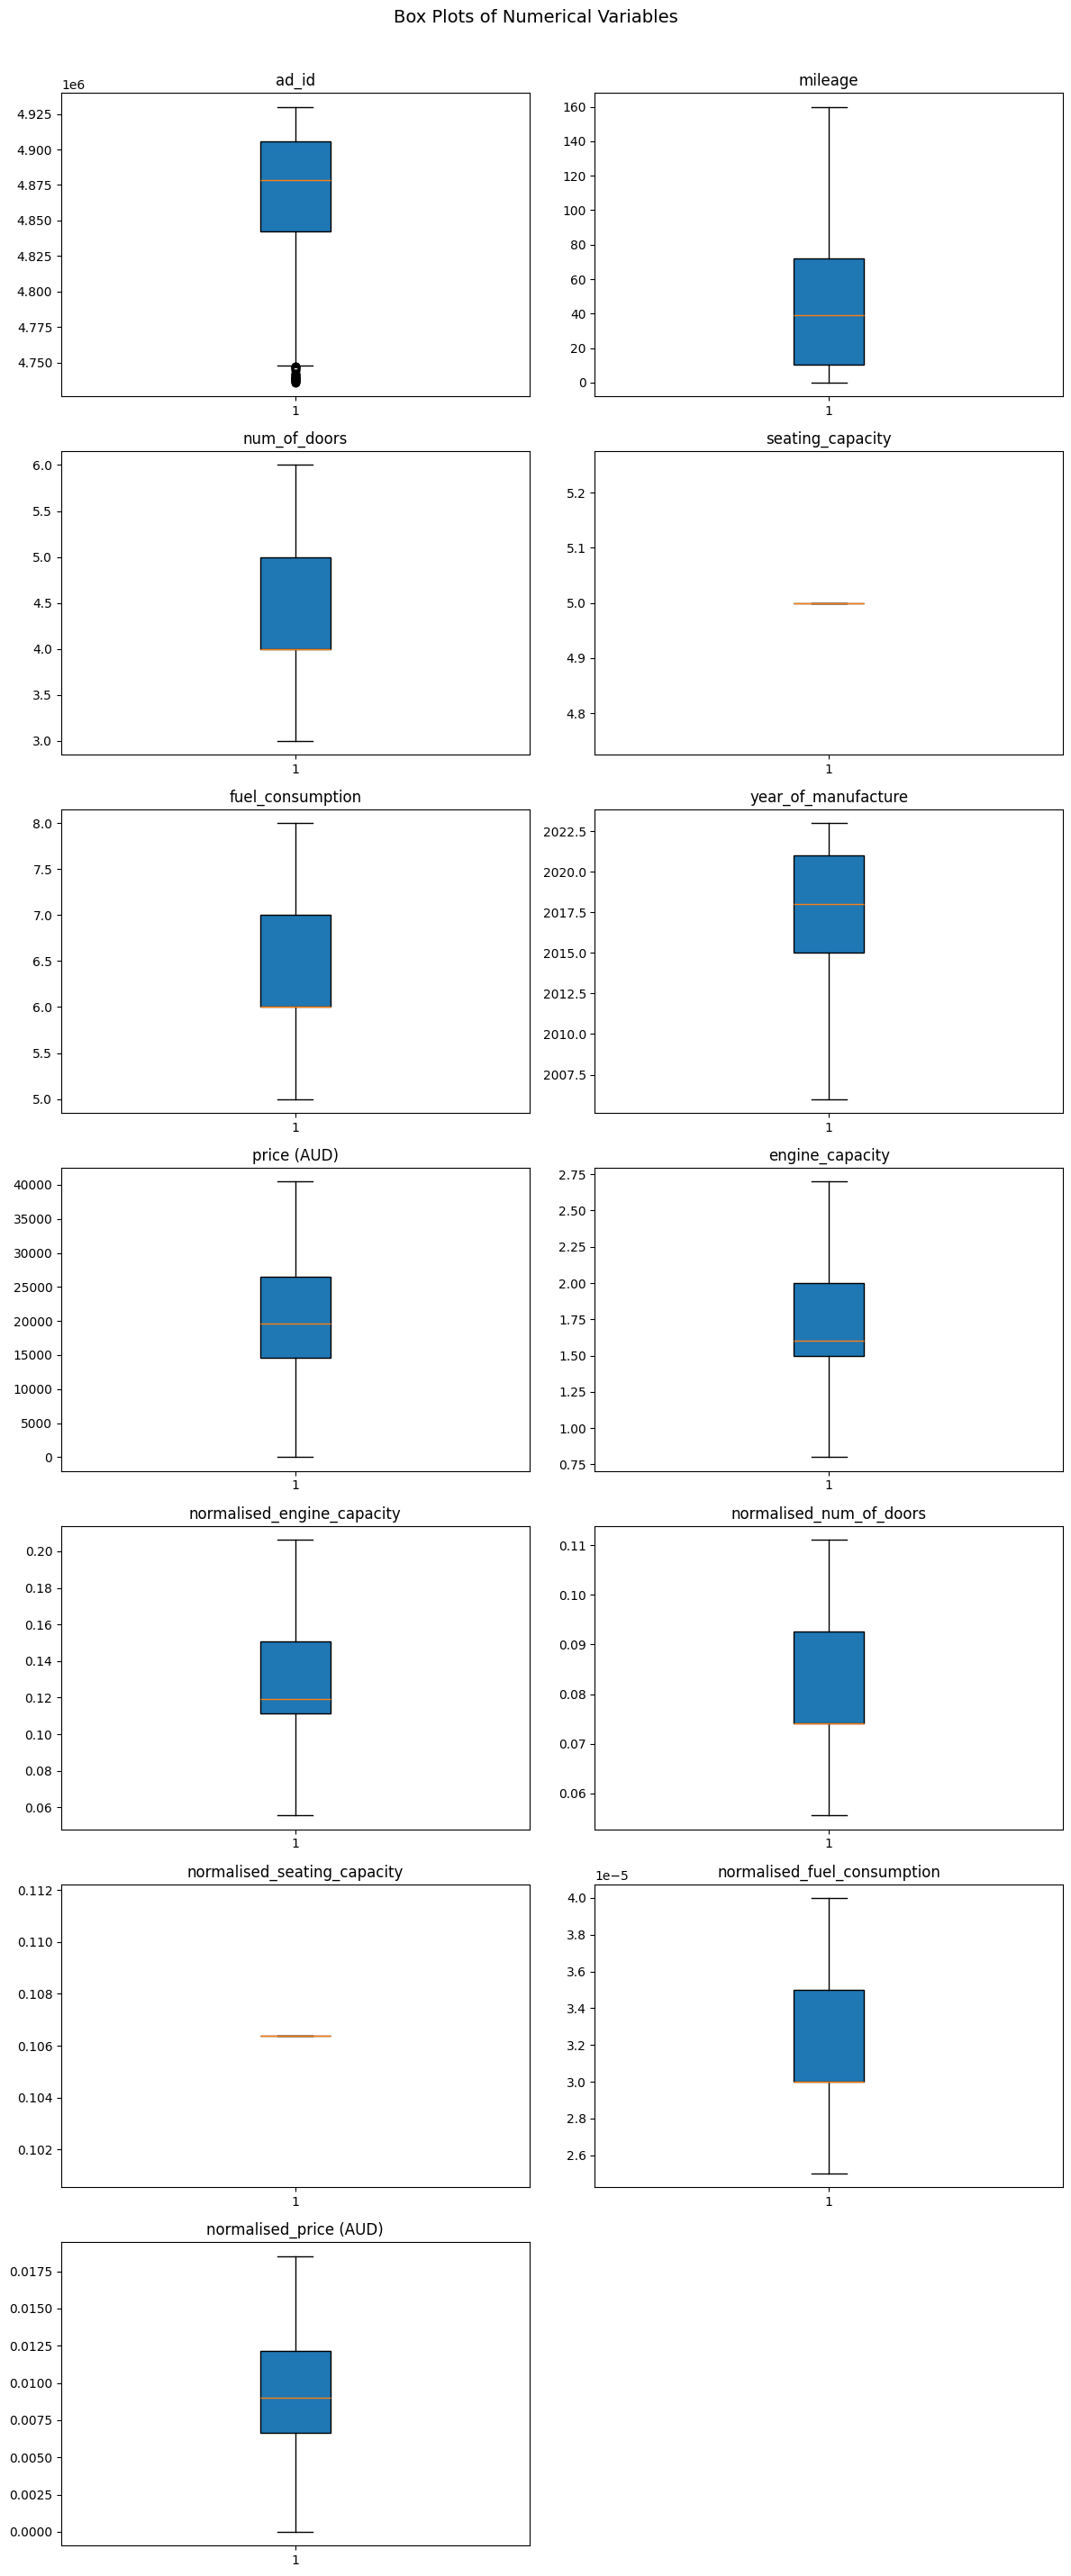

In [41]:
# Visualise boxplot to see outliers
numeric_cols = cleaned_car_data.select_dtypes(include=['float64', 'int64']).columns
n = len(numeric_cols)

cols = 2 #make it 2 cols
rows = (n + 1) // cols

fig, axs = plt.subplots(rows, cols, figsize=(12, 4 * rows)) #create graph
axs = axs.flatten()

# Create boxplot
for i, col in enumerate(numeric_cols): #create boxplot
    axs[i].boxplot(cleaned_car_data[col].dropna(), patch_artist=True)
    axs[i].set_title(col)

# Delete spaces
for j in range(i + 1, len(axs)):
    fig.delaxes(axs[j])

plt.tight_layout()
plt.suptitle("Box Plots of Numerical Variables", fontsize=14, y=1.02)
plt.show()